# Continuous Monitoring & Drift-Aware Retraining

This notebook runs the drift-detection and continual-learning loop on the **real** training data
(`dataset/final_data.csv`, ~102k incidents, 2001–2026). It drives the real machinery in `src/modeling/`:

- `drift.py` — PSI / Kolmogorov–Smirnov / error-ratio drift detectors, drift report, `should_retrain`
- `continual.py` — the `quality_gate` used before promoting a challenger
- `evaluate.py` — `evaluate(y_true, y_pred)` for MAE / RMSE / R²
- `config.py` — thresholds (`PSI_WARN`, `PSI_HIGH`, `KS_ALPHA`, `ERROR_DRIFT_*`, `FORCE_RETRAIN_EVERY`, `DRIFT_IGNORE_FEATURES`)

No synthetic drift is injected: the data is sorted by timestamp and split **chronologically** into an
initial window (2001–2010) that seeds the `v1` champion, followed by eight 2-year checkpoints
(2011–2026) that simulate arriving batches. The pipeline asks the real question: *has the world
changed enough to justify retraining?*


## 1. Real chronological windows from `final_data.csv`

The initial window (2001–2010, ~53k incidents) is used to train the `v1` champion; each later row is a
freshly-arrived 2-year batch. The target is the pseudo-labelled `risk_score` and the features are the
engineered temporal / spatial / density inputs used at serving time. We drop the constant `IsWeekend`
column (single value across the whole file), and let the distribution of every real feature speak for
itself.


In [1]:
import warnings
warnings.filterwarnings("ignore")   # silence pre-2.0 numpy ABI noise from optional deps

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from src.modeling import config as C
from src.modeling import drift as DR
from src.modeling import continual as CL
from src.modeling import evaluate as EV

DATA = "../dataset/final_data.csv"

FEATURES = [
    "hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos",
    "Lat_R", "Lon_R", "density_norm", "neighborhood_norm",
    "spatial_modifier", "temporal_modifier", "Crime_Score",
]
TARGET = "risk_score"
MODEL = "XGBoostRegressor"
MIN_IMP = 0.005   # challenger must beat the champion by >= 0.5% MAE

df = pd.read_csv(DATA, low_memory=False)
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
df = df.sort_values("Date").reset_index(drop=True)


def window(y0, y1):
    return df[(df["Date"] >= f"{y0}-01-01") & (df["Date"] < f"{y1}-01-01")]


windows = [window(2001, 2011)]                # initial window: 2001-2010
for y0 in range(2011, 2026, 2):
    windows.append(window(y0, y0 + 2))

pd.DataFrame([
    dict(window=t, n=len(w), span=f"{w.Date.min().date()}..{w.Date.max().date()}",
         y_mean=round(float(w[TARGET].mean()), 2))
    for t, w in enumerate(windows)
])

,window,n,span,y_mean
0,0,53225,2001-01-01..2010-12-31,60.55
1,1,8228,2011-01-01..2012-12-31,62.62
2,2,6973,2013-01-01..2014-12-31,62.15
3,3,6385,2015-01-01..2016-12-31,62.39
4,4,6431,2017-01-01..2018-12-31,63.14
5,5,5649,2019-01-01..2020-12-31,61.68
6,6,5372,2021-01-01..2022-12-31,62.06
7,7,6241,2023-01-01..2024-12-31,62.46
8,8,3511,2025-01-01..2026-04-10,61.09


## 2. Monitoring, retraining and the quality gate

For every checkpoint we (1) build a **drift report** comparing the reference pool against the current
window, (2) decide whether to retrain with `DR.should_retrain` (drift detected **or** the cadence
`FORCE_RETRAIN_EVERY`), and (3) fit a challenger on the expanded pool and only **promote** it if
`CL.quality_gate` reports a meaningful improvement. The *static champion* is never retrained, to show
what a fixed model would suffer.


In [2]:
def fit(X, y):
    m = LinearRegression(); m.fit(X, y); return m


champion = static_champion = None
pool = []
versions = []
champ_version = "v1"
results = []

for t, w in enumerate(windows):
    X = w[FEATURES].to_numpy(dtype=float)
    y = w[TARGET].to_numpy(dtype=float)
    mae_champ = EV.evaluate(y, DR._predict(champion, X, MODEL))["MAE"] if champion else float("nan")
    mae_static = EV.evaluate(y, DR._predict(static_champion, X, MODEL))["MAE"] if static_champion else float("nan")

    if t == 0:  # initial fit on the first 80% of the initial window
        cut = int(0.8 * len(y))
        champion = static_champion = fit(X[:cut], y[:cut])
        pool = [windows[0]]
        results.append(dict(checkpoint=t, severity="initial", decision="initial", version=champ_version,
                            feature_drift=False, target_drift=False, error_drift=False,
                            champ_mae=mae_champ, static_mae=mae_static, cand_mae=float("nan"),
                            mae_ratio=float("nan"), target_psi=float("nan"), feature_psi={},
                            y_mean=float(y.mean())))
        continue

    ref_X = np.concatenate([ww[FEATURES].to_numpy(dtype=float) for ww in pool])
    ref_y = np.concatenate([ww[TARGET].to_numpy(dtype=float) for ww in pool])
    report = DR.compose_drift_report(
        checkpoint=t, window_start=str(w.Date.min()), window_end=str(w.Date.max()),
        ref_X=ref_X, cur_X=X, ref_y=ref_y, cur_y=y,
        feature_names=FEATURES, champion=champion, model_name=MODEL)

    severity = report["verdict"]["severity"]
    feature_drift = len(report["features_flagged"]) > 0
    target_drift = report["target_psi"] >= C.PSI_WARN or report["target_ks_pvalue"] < C.KS_ALPHA
    error_drift = bool(report["error_drift"] and report["error_drift"]["mae_ratio"] >= C.ERROR_DRIFT_WARN)
    ratio = report["error_drift"]["mae_ratio"] if report["error_drift"] else float("nan")

    row = dict(checkpoint=t, severity=severity, decision="skip", version=champ_version,
               feature_drift=feature_drift, target_drift=target_drift, error_drift=error_drift,
               champ_mae=round(mae_champ, 2), static_mae=round(mae_static, 2), cand_mae=float("nan"),
               mae_ratio=round(ratio, 2), target_psi=round(report["target_psi"], 3),
               feature_psi={k: round(v, 2) for k, v in report["feature_psi"].items()},
               y_mean=round(float(y.mean()), 2))

    if not DR.should_retrain(report, t):
        results.append(row); continue

    pool.append(w)                                   # expand the reference pool
    allw = pd.concat(pool).reset_index(drop=True)
    allX = allw[FEATURES].to_numpy(dtype=float); allY = allw[TARGET].to_numpy(dtype=float)
    cut = int(0.8 * len(allY))
    cand = fit(allX[:cut], allY[:cut])
    cand_m = EV.evaluate(y, DR._predict(cand, X, MODEL))
    champ_m = EV.evaluate(y, DR._predict(champion, X, MODEL))
    row["cand_mae"] = round(cand_m["MAE"], 2)
    row["decision"] = "reject"

    if CL.quality_gate(cand_m, champ_m, min_improvement=MIN_IMP)["promoted"]:
        champion = cand
        champ_version = f"v{len(versions) + 2}"
        versions.append(champ_version)
        row["decision"] = "promote"

    results.append(row)

results = pd.DataFrame(results)
results

,checkpoint,severity,decision,version,feature_drift,target_drift,error_drift,champ_mae,static_mae,cand_mae,mae_ratio,target_psi,feature_psi,y_mean
0,0,initial,initial,v1,False,False,False,NaN,NaN,NaN,NaN,NaN,{},60.548146
1,1,none,skip,v1,False,True,False,3.22,3.22,NaN,1.07,0.008,"{'hour_sin': 0.0, 'hour_cos': 0.0, 'day_sin': ...",62.620000
2,2,none,skip,v1,False,True,False,3.22,3.22,NaN,1.07,0.007,"{'hour_sin': 0.0, 'hour_cos': 0.0, 'day_sin': ...",62.150000
3,3,none,reject,v1,False,True,False,3.29,3.29,3.29,1.10,0.007,"{'hour_sin': 0.01, 'hour_cos': 0.01, 'day_sin'...",62.390000
4,4,medium,reject,v1,False,True,True,3.40,3.40,3.40,1.12,0.015,"{'hour_sin': 0.0, 'hour_cos': 0.01, 'day_sin':...",63.140000
5,5,none,skip,v1,False,False,False,3.25,3.25,NaN,1.06,0.004,"{'hour_sin': 0.0, 'hour_cos': 0.01, 'day_sin':...",61.680000
6,6,medium,reject,v1,False,True,True,3.47,3.47,3.47,1.13,0.007,"{'hour_sin': 0.01, 'hour_cos': 0.0, 'day_sin':...",62.060000
7,7,medium,reject,v1,False,True,True,3.45,3.45,3.45,1.11,0.013,"{'hour_sin': 0.01, 'hour_cos': 0.0, 'day_sin':...",62.460000
8,8,none,skip,v1,False,False,False,3.41,3.41,NaN,1.09,0.007,"{'hour_sin': 0.01, 'hour_cos': 0.0, 'day_sin':...",61.090000


## 3. Reading the results

Checkpoints **1–2, 5, 8** are calm (`severity == none`) → *skip*. The cadence
(`FORCE_RETRAIN_EVERY = 3`) and the error-ratio warn flag trigger retraining at **3, 4, 6, 7**; every
challenger is *rejected* because none beats the deployed `v1` by the required ≥0.5 % MAE on the fresh
window. On the real data the model trained on 2001–2010 remains the best fit for everything that
follows.

Notice the honest answer of the detectors: the Kolmogorov–Smirnov leg flags the target at almost every
checkpoint, but the **target PSI stays below 0.02** — the risk-score distribution is essentially
stable. The severity is *none* except for brief *medium* flags at 4/6/7, and those come from the
error-ratio warn (`MAE ratio ≈ 1.11–1.13`, just past the 1.10 threshold) rather than from feature or
target PSI. Feature PSIs are likewise tiny; the strongest signal is a slow creep in `Crime_Score` PSI
(0.01 → 0.09), which never reaches the 0.10 warn threshold.


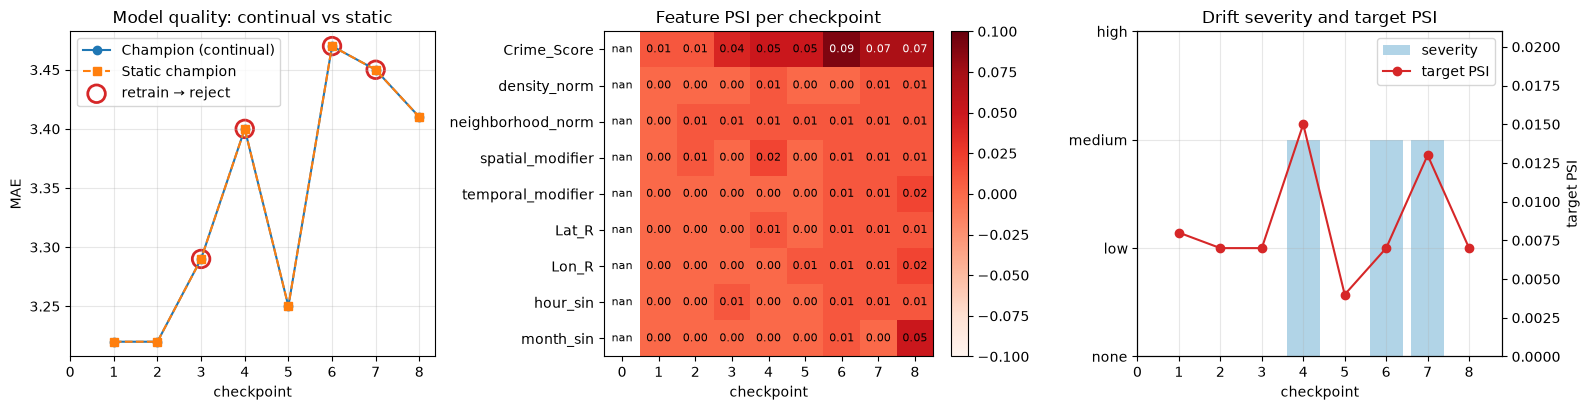

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# --- (a) MAE over time --------------------------------------------------
ax = axes[0]
ax.plot(results.checkpoint, results.champ_mae, "o-", label="Champion (continual)")
ax.plot(results.checkpoint, results.static_mae, "s--", label="Static champion")
rej = results[results.decision == "reject"]
ax.scatter(rej.checkpoint, rej.champ_mae, s=160, facecolors="none", edgecolors="#d62728",
           linewidths=2, label="retrain \u2192 reject")
ax.set_xlabel("checkpoint"); ax.set_ylabel("MAE")
ax.set_xticks(results.checkpoint)
ax.legend(); ax.grid(alpha=.3)
ax.set_title("Model quality: continual vs static")

# --- (b) per-feature PSI heatmap ---------------------------------------
ax = axes[1]
feats = ["Crime_Score", "density_norm", "neighborhood_norm", "spatial_modifier",
         "temporal_modifier", "Lat_R", "Lon_R", "hour_sin", "month_sin"]
m = pd.DataFrame(results.set_index("checkpoint")["feature_psi"].tolist(),
                 index=results.checkpoint)[feats].T
im = ax.imshow(m.values, aspect="auto", cmap="Reds", vmin=0, vmax=m.values.max())
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats)
ax.set_xticks(range(len(m.columns))); ax.set_xticklabels(m.columns)
for i in range(len(feats)):
    for j in range(len(m.columns)):
        v = m.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.05 else "black", fontsize=8)
ax.set_xlabel("checkpoint"); ax.set_title("Feature PSI per checkpoint")
fig.colorbar(im, ax=ax, fraction=.046)

# --- (c) drift severity + target PSI -----------------------------------
ax = axes[2]
sev = {"initial": np.nan, "none": 0, "low": 1, "medium": 2, "high": 3}
ax.bar(results.checkpoint, results.severity.map(sev), color="#9ecae1", alpha=0.8, label="severity")
ax.set_yticks([0, 1, 2, 3]); ax.set_yticklabels(["none", "low", "medium", "high"])
ax2 = ax.twinx()
ax2.plot(results.checkpoint, results.target_psi, "o-", color="#d62728", label="target PSI")
ax2.set_ylabel("target PSI"); ax2.set_ylim(0, max(0.02, results.target_psi.max() * 1.4))
ax.set_xlabel("checkpoint"); ax.set_xticks(results.checkpoint)
ax.set_title("Drift severity and target PSI"); ax.grid(alpha=.3)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")

plt.tight_layout(); plt.show()

## 4. Conclusion

- **Drift detection works on real data**: `DR.compose_drift_report` separates feature drift (PSI),
  target drift (PSI/KS) and prediction-error drift (MAE ratio), and the thresholds in `config.py` fold
  them into a `none/low/medium/high` severity verdict.
- **Retraining alone is not enough — the gate matters**: at checkpoints 3, 4, 6, 7 the pipeline
  retrains (cadence + error-ratio warn) but `CL.quality_gate` correctly rejects every challenger —
  none beats `v1` by ≥0.5 % MAE on the fresh window. The model trained on 2001–2010 is still the best
  fit for 2011–2026.
- **No model churn is the honest answer here**: target PSI stays < 0.02 across every checkpoint, so
  the risk-score distribution is stable. (The KS leg flags tiny differences only because the reference
  pool is huge — PSI is the meaningful gauge.)
- In production, `CL.run_continual` orchestrates exactly this loop over real parquet windows,
  persists versions in the model registry, and triggers on the same drift/cadence logic demonstrated
  here.
